In [1]:
!pip install kagglehub xgboost lightgbm catboost shap lime -q

import kagglehub, os, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings('ignore')

# ML
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.pipeline import Pipeline

from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# DL
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

# XAI
import shap
import lime, lime.lime_tabular

print("✅ All libraries imported!")
print(f"TensorFlow version : {tf.__version__}")

✅ All libraries imported!
TensorFlow version : 2.20.0


In [2]:
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")
print("📁 Dataset path:", path)

# CSV খোঁজো
for root, dirs, files in os.walk(path):
    for f in files:
        print(os.path.join(root, f))

📁 Dataset path: /kaggle/input/datasets/organizations/uciml/breast-cancer-wisconsin-data
/kaggle/input/datasets/organizations/uciml/breast-cancer-wisconsin-data/data.csv


In [3]:
csv_path = os.path.join(path, "data.csv")
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
df.head()

Shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
print(df.isnull().sum()[df.isnull().sum() > 0])

Unnamed: 32    569
dtype: int64


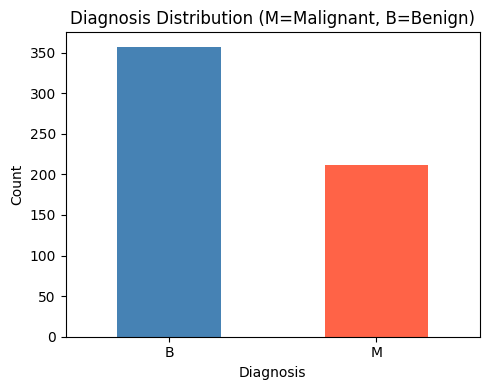

In [6]:
plt.figure(figsize=(5, 4))
df['diagnosis'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Diagnosis Distribution (M=Malignant, B=Benign)')
plt.xlabel('Diagnosis'); plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

In [7]:
df.drop(['id', 'Unnamed: 32'], axis=1, inplace=True, errors='ignore')

In [8]:
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])

In [9]:
print("After encoding — unique labels:", df['diagnosis'].unique())
print("Shape:", df.shape)
df.head(3)

After encoding — unique labels: [1 0]
Shape: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


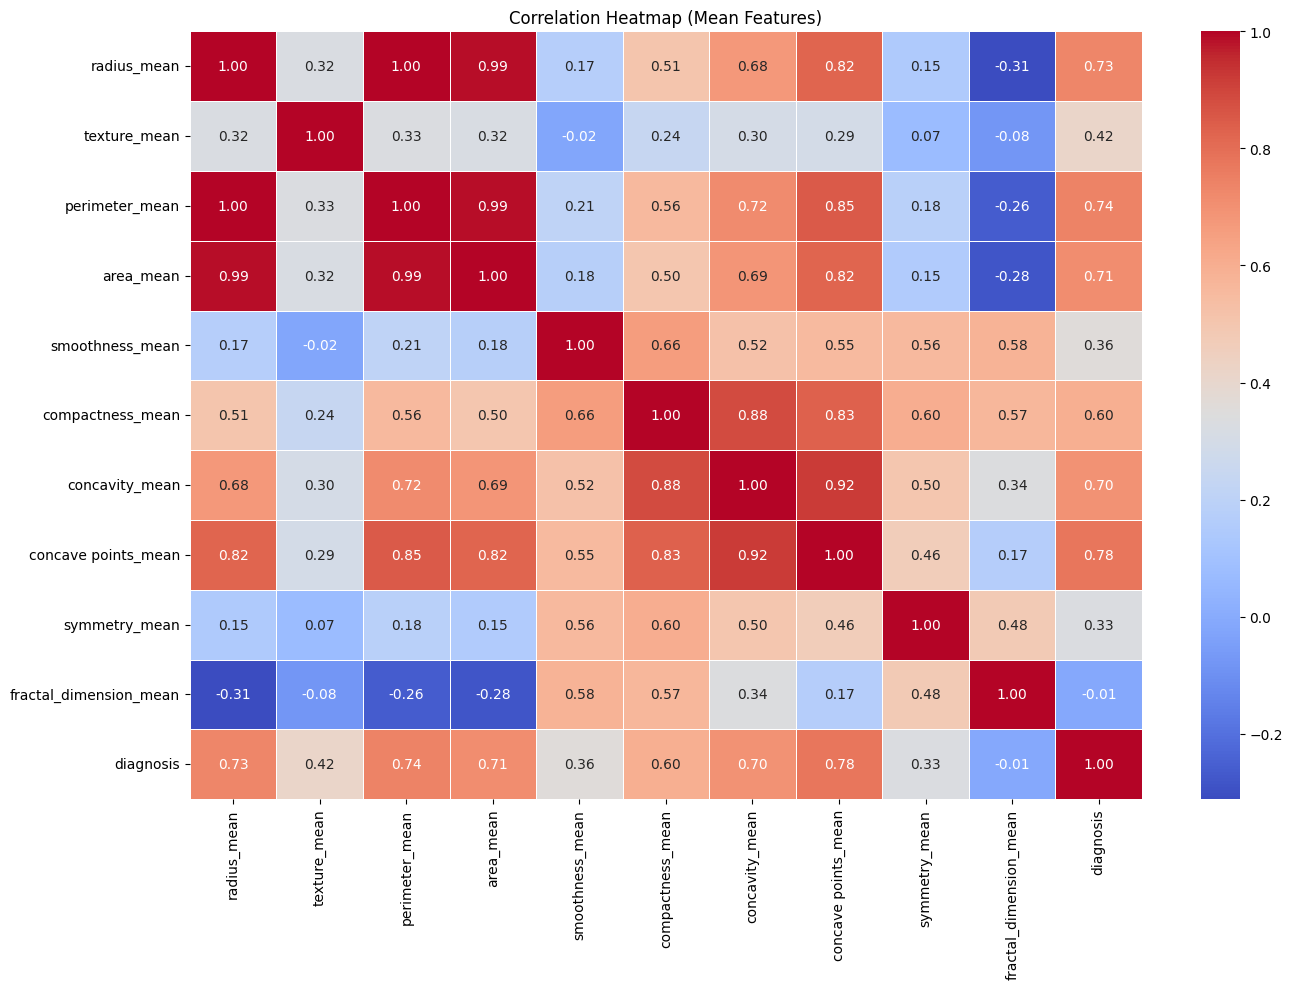

✅ Feature Engineering done — New shape: (569, 33)


In [10]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

feature_names = X.columns.tolist()

# --- 6a. Correlation heatmap (mean features only) ---
mean_cols = [c for c in X.columns if '_mean' in c]

plt.figure(figsize=(14, 10))
sns.heatmap(df[mean_cols + ['diagnosis']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm', linewidths=.5)
plt.title('Correlation Heatmap (Mean Features)')
plt.tight_layout(); plt.show()

# --- 6b. New ratio features ---
X = X.copy()
X['radius_texture_ratio']    = X['radius_mean']    / (X['texture_mean']    + 1e-6)
X['area_perimeter_ratio']    = X['area_mean']      / (X['perimeter_mean']  + 1e-6)
X['concavity_symmetry_ratio']= X['concavity_mean'] / (X['symmetry_mean']   + 1e-6)

print("✅ Feature Engineering done — New shape:", X.shape)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train_sc.shape}  |  Test: {X_test_sc.shape}")

Train: (455, 33)  |  Test: (114, 33)


In [12]:
results = {}   # সব model এর result store করবো

def evaluate(name, model, X_tr, X_te, y_tr, y_te, is_nn=False):
    """Train, evaluate and store results."""
    if not is_nn:
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        try:
            y_prob = model.predict_proba(X_te)[:, 1]
        except:
            y_prob = y_pred
    else:
        y_pred = (model.predict(X_te) > 0.5).astype(int).ravel()
        y_prob = model.predict(X_te).ravel()

    acc = accuracy_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_prob)
    results[name] = {'Accuracy': acc, 'ROC-AUC': auc}

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  ROC-AUC  : {auc:.4f}")
    print(classification_report(y_te, y_pred,
          target_names=['Benign','Malignant']))

    # Confusion Matrix
    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign','Malignant'],
                yticklabels=['Benign','Malignant'])
    plt.title(f'{name} — Confusion Matrix')
    plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.tight_layout(); plt.show()

    return y_prob


  Logistic Regression
  Accuracy : 0.9825
  ROC-AUC  : 0.9960
              precision    recall  f1-score   support

      Benign       0.97      1.00      0.99        72
   Malignant       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



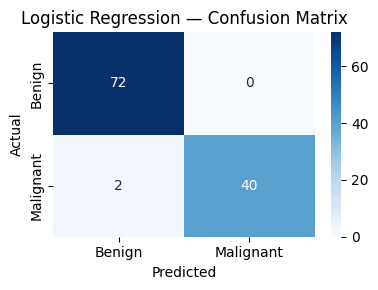

In [13]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr_prob = evaluate('Logistic Regression', lr,
                   X_train_sc, X_test_sc, y_train, y_test)


  Random Forest
  Accuracy : 0.9737
  ROC-AUC  : 0.9957
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



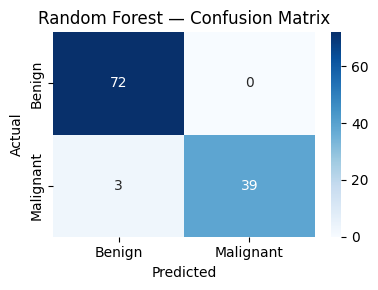

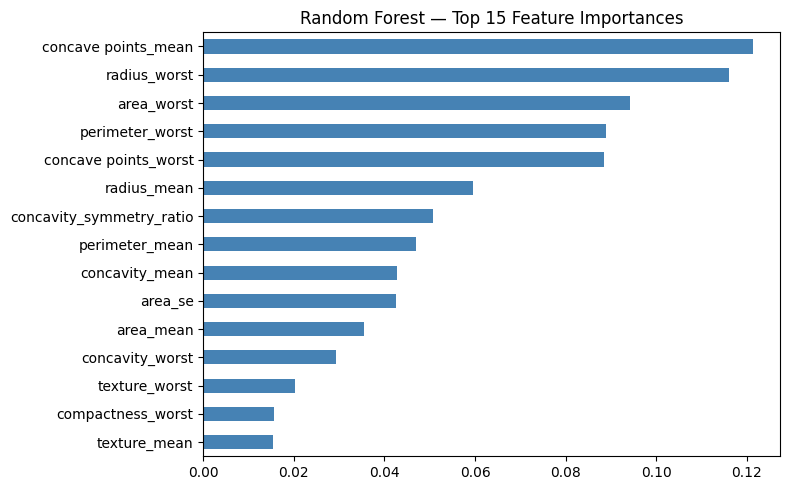

In [14]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_prob = evaluate('Random Forest', rf,
                   X_train_sc, X_test_sc, y_train, y_test)

# Feature importance
feat_imp = pd.Series(rf.feature_importances_,
                     index=X.columns).sort_values(ascending=False)[:15]
plt.figure(figsize=(8, 5))
feat_imp.plot(kind='barh', color='steelblue')
plt.title('Random Forest — Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()


  XGBoost
  Accuracy : 0.9649
  ROC-AUC  : 0.9917
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



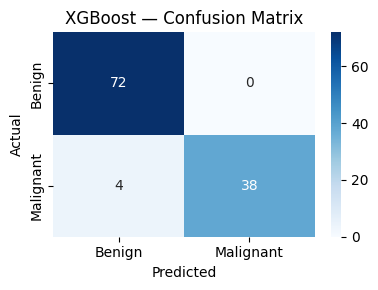

In [15]:
xgb = XGBClassifier(n_estimators=300, learning_rate=0.05,
                    max_depth=4, use_label_encoder=False,
                    eval_metric='logloss', random_state=42)
xgb_prob = evaluate('XGBoost', xgb,
                    X_train_sc, X_test_sc, y_train, y_test)


  LightGBM
  Accuracy : 0.9737
  ROC-AUC  : 0.9944
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



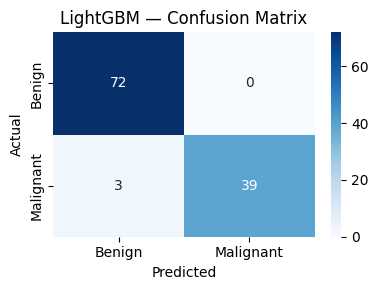

In [16]:
lgb = LGBMClassifier(n_estimators=300, learning_rate=0.05,
                     max_depth=4, random_state=42, verbose=-1)
lgb_prob = evaluate('LightGBM', lgb,
                    X_train_sc, X_test_sc, y_train, y_test)


  CatBoost
  Accuracy : 0.9649
  ROC-AUC  : 0.9957
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



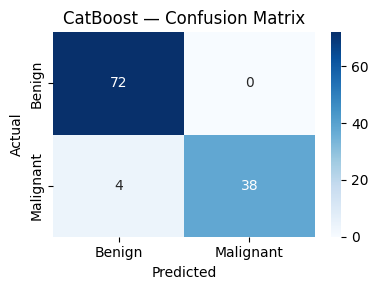

In [17]:
cb = CatBoostClassifier(iterations=300, learning_rate=0.05,
                        depth=4, random_state=42, verbose=0)
cb_prob = evaluate('CatBoost', cb,
                   X_train_sc, X_test_sc, y_train, y_test)

I0000 00:00:1783259790.782286      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783259790.785011      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1783259794.350470     219 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


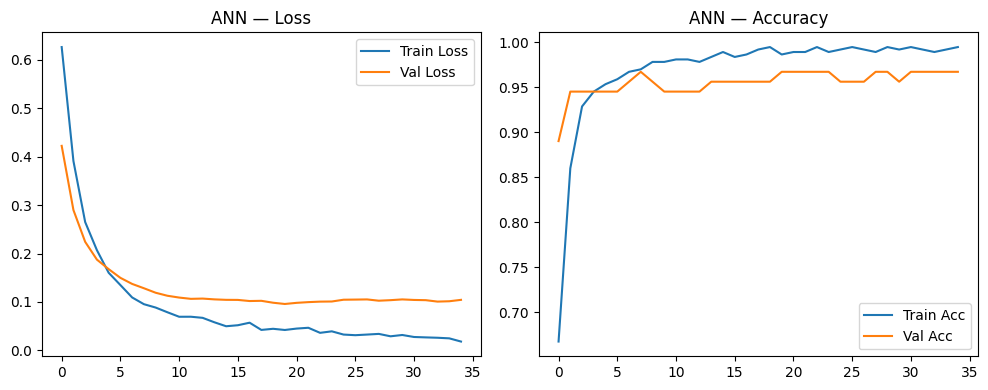

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

  ANN
  Accuracy : 0.9825
  ROC-AUC  : 0.9974
              precision    recall  f1-score   support

      Benign       0.97      1.00      0.99        72
   Malignant       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



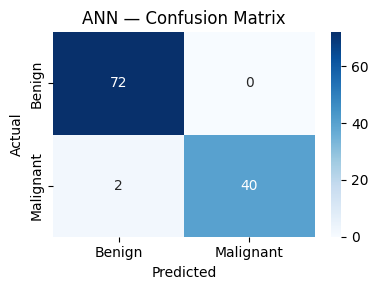

In [18]:
def build_ann(input_dim):
    model = Sequential([
        Dense(64, activation='relu', input_dim=input_dim),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1,  activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

ann = build_ann(X_train_sc.shape[1])
es  = EarlyStopping(patience=15, restore_best_weights=True, verbose=0)

history_ann = ann.fit(X_train_sc, y_train,
                      validation_split=0.2,
                      epochs=150, batch_size=32,
                      callbacks=[es], verbose=0)

# Training curves
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
plt.plot(history_ann.history['loss'],    label='Train Loss')
plt.plot(history_ann.history['val_loss'],label='Val Loss')
plt.title('ANN — Loss'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history_ann.history['accuracy'],    label='Train Acc')
plt.plot(history_ann.history['val_accuracy'],label='Val Acc')
plt.title('ANN — Accuracy'); plt.legend()
plt.tight_layout(); plt.show()

ann_prob = evaluate('ANN', ann,
                    X_train_sc, X_test_sc, y_train, y_test,
                    is_nn=True)

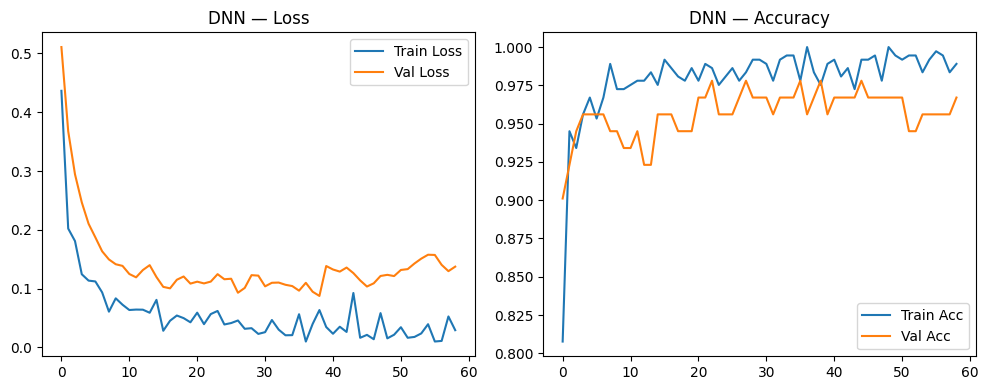

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 150ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

  DNN
  Accuracy : 0.9737
  ROC-AUC  : 0.9888
              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98        72
   Malignant       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



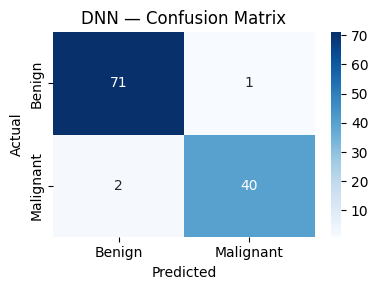

In [19]:
def build_dnn(input_dim):
    model = Sequential([
        Dense(256, activation='relu', input_dim=input_dim),
        BatchNormalization(),
        Dropout(0.4),

        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),

        Dense(32, activation='relu'),
        Dense(1,  activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

dnn = build_dnn(X_train_sc.shape[1])
es2 = EarlyStopping(patience=20, restore_best_weights=True, verbose=0)

history_dnn = dnn.fit(X_train_sc, y_train,
                      validation_split=0.2,
                      epochs=200, batch_size=32,
                      callbacks=[es2], verbose=0)

# Training curves
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
plt.plot(history_dnn.history['loss'],    label='Train Loss')
plt.plot(history_dnn.history['val_loss'],label='Val Loss')
plt.title('DNN — Loss'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history_dnn.history['accuracy'],    label='Train Acc')
plt.plot(history_dnn.history['val_accuracy'],label='Val Acc')
plt.title('DNN — Accuracy'); plt.legend()
plt.tight_layout(); plt.show()

dnn_prob = evaluate('DNN', dnn,
                    X_train_sc, X_test_sc, y_train, y_test,
                    is_nn=True)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:57:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



  Voting Ensemble (ML)
  Accuracy : 0.9737
  ROC-AUC  : 0.9964
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



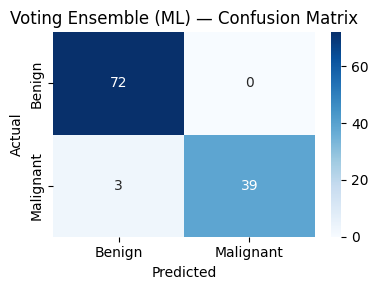


  Hybrid Ensemble (Voting ML + DNN)
  Accuracy : 0.9825
  ROC-AUC  : 0.9950
              precision    recall  f1-score   support

      Benign       0.97      1.00      0.99        72
   Malignant       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [20]:
voting = VotingClassifier(
    estimators=[('lr',  lr),
                ('rf',  rf),
                ('xgb', xgb),
                ('lgb', lgb),
                ('cb',  cb)],
    voting='soft', n_jobs=-1)

voting_prob = evaluate('Voting Ensemble (ML)', voting,
                       X_train_sc, X_test_sc, y_train, y_test)

# --- 16b. Hybrid Avg: ML Voting + DNN ---
hybrid_prob = (voting_prob * 0.5 + dnn_prob * 0.5)
hybrid_pred = (hybrid_prob > 0.5).astype(int)

acc = accuracy_score(y_test, hybrid_pred)
auc = roc_auc_score(y_test, hybrid_prob)
results['Hybrid Ensemble'] = {'Accuracy': acc, 'ROC-AUC': auc}

print(f"\n{'='*50}")
print("  Hybrid Ensemble (Voting ML + DNN)")
print(f"{'='*50}")
print(f"  Accuracy : {acc:.4f}")
print(f"  ROC-AUC  : {auc:.4f}")
print(classification_report(y_test, hybrid_pred,
      target_names=['Benign','Malignant']))

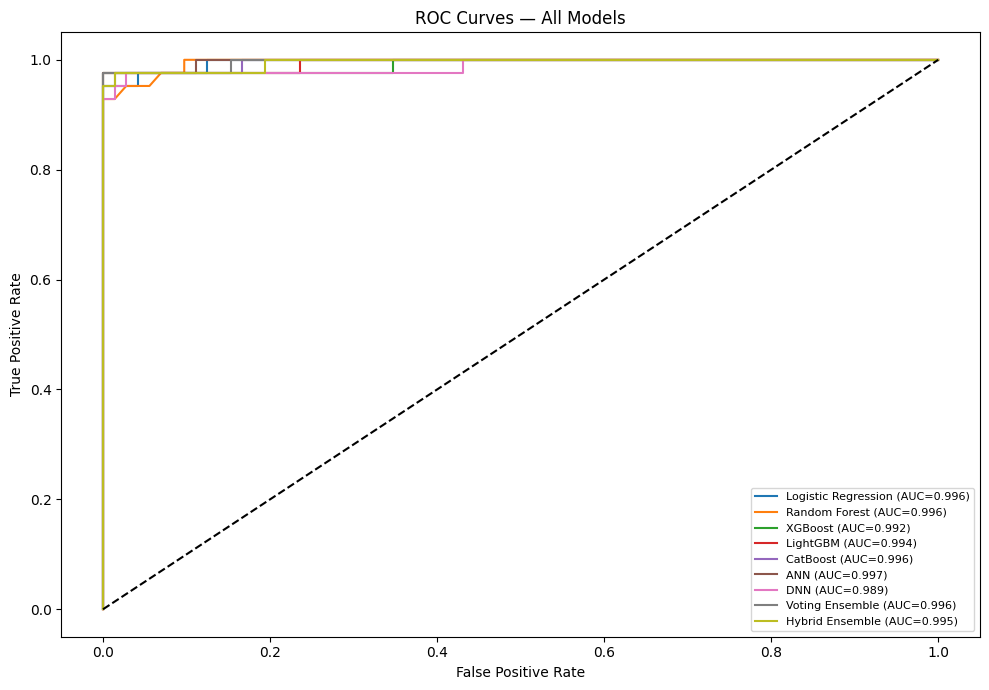

In [21]:
probs = {
    'Logistic Regression': lr_prob,
    'Random Forest'       : rf_prob,
    'XGBoost'             : xgb_prob,
    'LightGBM'            : lgb_prob,
    'CatBoost'            : cb_prob,
    'ANN'                 : ann_prob,
    'DNN'                 : dnn_prob,
    'Voting Ensemble'     : voting_prob,
    'Hybrid Ensemble'     : hybrid_prob,
}

plt.figure(figsize=(10, 7))
for name, prob in probs.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.show()


📊 Model Comparison:
                      Accuracy   ROC-AUC
ANN                   0.982456  0.997354
Voting Ensemble (ML)  0.973684  0.996362
Logistic Regression   0.982456  0.996032
CatBoost              0.964912  0.995701
Random Forest         0.973684  0.995701
Hybrid Ensemble       0.982456  0.995040
LightGBM              0.973684  0.994378
XGBoost               0.964912  0.991733
DNN                   0.973684  0.988757


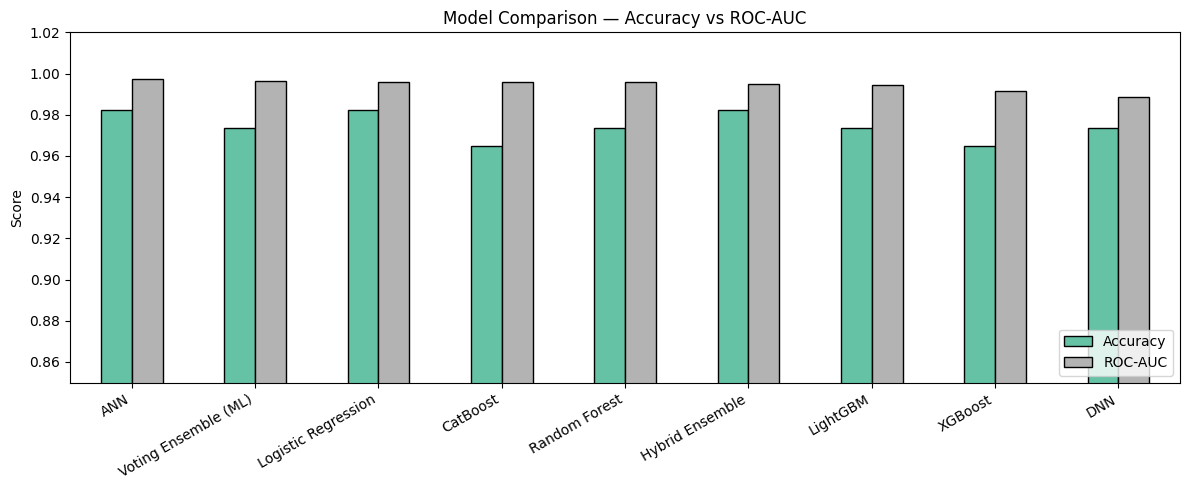

In [22]:
results_df = pd.DataFrame(results).T.sort_values('ROC-AUC', ascending=False)
print("\n📊 Model Comparison:")
print(results_df.to_string())

# Bar plot
results_df.plot(kind='bar', figsize=(12, 5), colormap='Set2', edgecolor='black')
plt.title('Model Comparison — Accuracy vs ROC-AUC')
plt.ylabel('Score')
plt.xticks(rotation=30, ha='right')
plt.ylim(0.85, 1.02)
plt.legend(loc='lower right')
plt.tight_layout(); plt.show()

🔍 SHAP Explainability (XGBoost)...


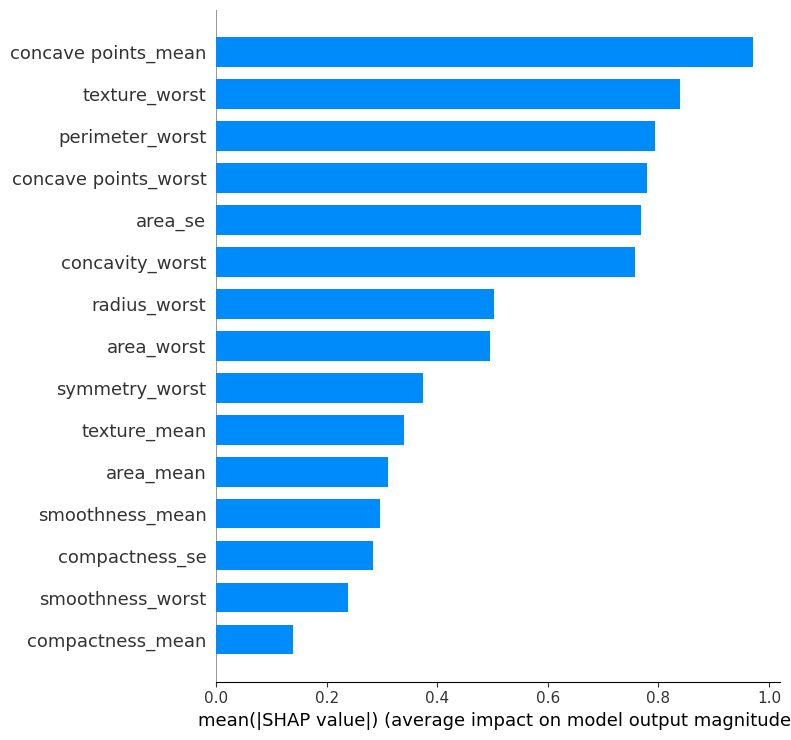

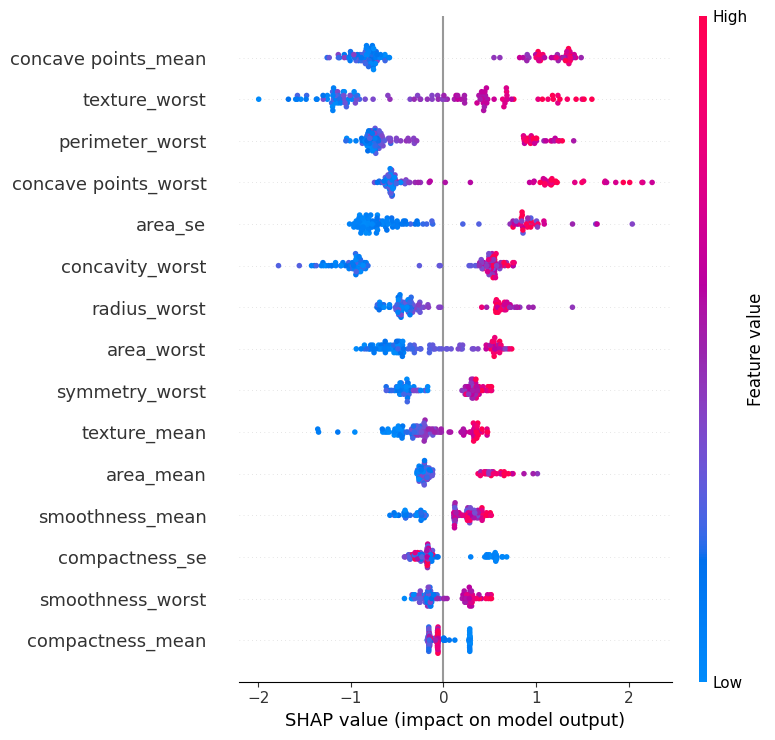


📌 SHAP Force Plot (Sample index 0):


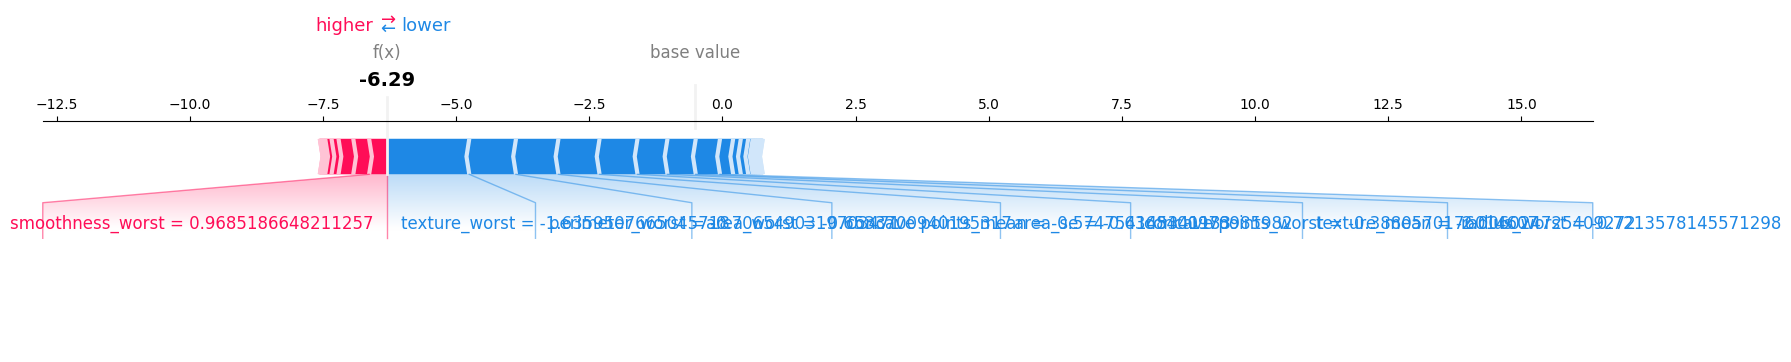

<Figure size 640x480 with 0 Axes>

In [23]:
print("🔍 SHAP Explainability (XGBoost)...")

explainer_shap = shap.TreeExplainer(xgb)
shap_values    = explainer_shap.shap_values(X_test_sc)

# Convert back to DataFrame for labels
X_test_df = pd.DataFrame(X_test_sc, columns=X.columns)

# Summary plot
plt.figure()
shap.summary_plot(shap_values, X_test_df, plot_type='bar',
                  show=True, max_display=15)

# Beeswarm
plt.figure()
shap.summary_plot(shap_values, X_test_df,
                  show=True, max_display=15)

# Force plot — single prediction
print("\n📌 SHAP Force Plot (Sample index 0):")
shap.initjs()
shap.force_plot(explainer_shap.expected_value,
                shap_values[0],
                X_test_df.iloc[0],
                matplotlib=True)
plt.tight_layout(); plt.show()


True label      : Benign
Predicted label : Benign


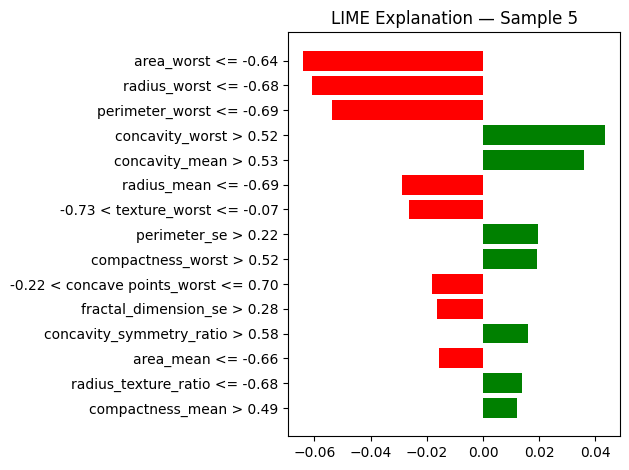

In [24]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data   = X_train_sc,
    feature_names   = X.columns.tolist(),
    class_names     = ['Benign', 'Malignant'],
    mode            = 'classification',
    random_state    = 42
)

# Explain one test instance
idx = 5
exp = lime_explainer.explain_instance(
    data_row        = X_test_sc[idx],
    predict_fn      = rf.predict_proba,
    num_features    = 15
)

print(f"\nTrue label      : {'Malignant' if y_test.iloc[idx]==1 else 'Benign'}")
print(f"Predicted label : {'Malignant' if rf.predict(X_test_sc[idx:idx+1])[0]==1 else 'Benign'}")

exp.as_pyplot_figure()
plt.title(f'LIME Explanation — Sample {idx}')
plt.tight_layout(); plt.show()

In [25]:
cv_models = {
    'Logistic Regression': lr,
    'Random Forest'      : rf,
    'XGBoost'            : xgb,
    'LightGBM'           : lgb,
    'CatBoost'           : cb,
}

print("📊 5-Fold Cross-Validation Results (ROC-AUC):")
print("="*45)
for name, model in cv_models.items():
    scores = cross_val_score(model, X_train_sc, y_train,
                             cv=5, scoring='roc_auc', n_jobs=-1)
    print(f"  {name:<25} {scores.mean():.4f} ± {scores.std():.4f}")

📊 5-Fold Cross-Validation Results (ROC-AUC):
  Logistic Regression       0.9956 ± 0.0053
  Random Forest             0.9895 ± 0.0131


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:57:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:57:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:57:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:57:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

  XGBoost                   0.9906 ± 0.0112


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  LightGBM                  0.9934 ± 0.0081
  CatBoost                  0.9927 ± 0.0087


In [26]:
print(results_df.to_string())
print("\n Best Model by ROC-AUC:", results_df['ROC-AUC'].idxmax())
print(" Best Model by Accuracy :", results_df['Accuracy'].idxmax())
print("\n Project Complete!")

                      Accuracy   ROC-AUC
ANN                   0.982456  0.997354
Voting Ensemble (ML)  0.973684  0.996362
Logistic Regression   0.982456  0.996032
CatBoost              0.964912  0.995701
Random Forest         0.973684  0.995701
Hybrid Ensemble       0.982456  0.995040
LightGBM              0.973684  0.994378
XGBoost               0.964912  0.991733
DNN                   0.973684  0.988757

 Best Model by ROC-AUC: ANN
 Best Model by Accuracy : ANN

 Project Complete!
